## Notebook Summary

In this notebook PPG motion artifact removal is undertaken via wiener, lms, nlms, and rls filtering. 

In [1]:
# Imports

import wfdb
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

%matplotlib widget

In [2]:
# Load Data

# Stream single record directly from PhysioNet: PPG and ECG peaks
record = wfdb.rdrecord('s3_walk', 
                        pn_dir='wrist/1.0.0')
annotation = wfdb.rdann('s3_walk', 
                         extension='atr',
                         pn_dir='wrist/1.0.0')

fs = 256
ppg_raw = record.p_signal[:, 1]
accel_x = record.p_signal[:, 5]
accel_y = record.p_signal[:, 6]
accel_z = record.p_signal[:, 7]
r_peaks = annotation.sample

# Combine accel channels
accel_raw = accel_x + accel_y + accel_z

In [3]:
# Pre-processing

# Clip signal length
t1 = 30
t2 = 60
t = np.arange(t1, t2, 1. / fs)
ppg = ppg_raw[fs * t1:fs * t2]
accel = accel_raw[fs * t1:fs * t2]

# Make sure no NaNs
assert sum(np.isnan(ppg)) == 0, "NaNs found in ppg"
assert sum(np.isnan(accel)) == 0, "NaNs found in accel"

# Bandpass filter: 0.5 to 5 Hz (impulse and freq response checked for stability and performance)
order = 4
sos = signal.butter(order, [0.5, 5.0], btype='band', fs=fs, output='sos') 

# Apply BPF to both ppg and accel data
ppg_filt = signal.sosfiltfilt(sos, ppg)
accel_filt = signal.sosfiltfilt(sos, accel)

# Normalize: PPG and accel data in different units on different scales
ppg_norm = (ppg_filt - np.mean(ppg_filt)) / np.std(ppg_filt)
accel_norm = (accel_filt - np.mean(accel_filt)) / np.std(accel_filt)

# Wiener Filter

In [4]:
# Wiener filter

N = len(ppg_norm)
M = 32

R = np.zeros((M, M))
p = np.zeros(M)

for n in range(M, N):
    x_n = accel_norm[n - M:n]
    R += np.outer(x_n, x_n)
    p += ppg_norm[n] * x_n

R /= (N - M)
p /= (N - M)

lambda_reg = 1e-5
w_wiener = np.linalg.solve(R + lambda_reg * np.eye(M), p)

y_wiener = signal.filtfilt(w_wiener, [1.0], accel_norm)
e_wiener = ppg_norm - y_wiener

var_removed = np.var(ppg_norm) - np.var(e_wiener)
pct_removed = 100 * var_removed / np.var(ppg_norm)
print(f"Variance removed: {pct_removed:.2f}%")

Variance removed: 36.09%


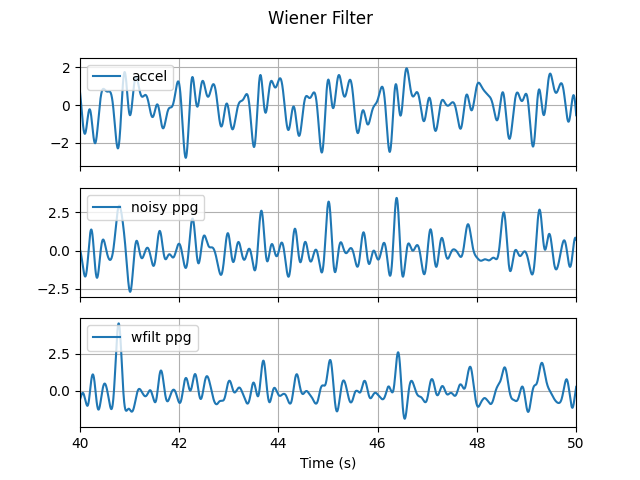

In [5]:
# Plot
fig, ax = plt.subplots(3,1, sharex=True)
ax[0].plot(t, accel_norm, label='accel')
ax[1].plot(t, ppg_norm, label='noisy ppg')
ax[2].plot(t, e_wiener, label='wfilt ppg')
ax[2].set_xlabel('Time (s)')
fig.suptitle('Wiener Filter')
for axi in ax:
    axi.legend(loc='upper left')
    axi.grid(True)
    axi.set_xlim(40, 50)


## Wiener filter notes:

- 36% variance reduction from noisy ppg to Wiener filtered PPG
- Periodicity in the filtered ppg is almost less visible than in the noisy signal
    - if dominant content in ppg and accel signals overlap in frequency, some unintended removal could have occurred
- Wiener assumes constant noise statistics over entire period (30s), so even if less variance in output signal, adaptive methods will be more suited

# LMS Adaptive Filter

In [6]:
# LMS Adaptive filter implementation

mu = 0.0001

input_power = np.mean(accel_norm**2)
mu_max = 1 / (M * input_power)
print(f"mu_max: {mu_max:.6f}")
print(f"mu: {mu:.6f}")

w_lms = np.zeros(M)
e_lms = np.zeros(N)

for n in range(M, N):
    x_n = accel_norm[n - M : n]
    y_n = np.dot(w_lms, x_n)
    e_lms[n] = ppg_norm[n] - y_n
    w_lms += 2 * mu * e_lms[n] * x_n

var_removed = np.var(ppg_norm) - np.var(e_lms)
pct_removed = 100 * var_removed / np.var(ppg_norm)
print(f"Variance removed: {pct_removed:.2f}%")

mu_max: 0.031250
mu: 0.000100
Variance removed: 54.81%


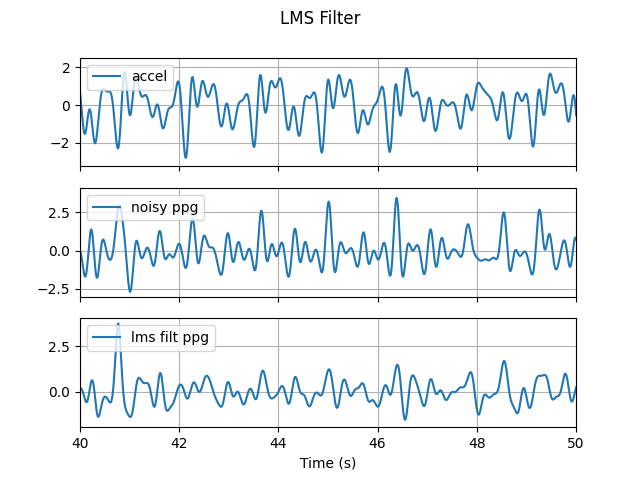

In [7]:
# Plot
fig, ax = plt.subplots(3,1, sharex=True)
ax[0].plot(t, accel_norm, label='accel')
ax[1].plot(t, ppg_norm, label='noisy ppg')
ax[2].plot(t, e_lms, label='lms filt ppg')
ax[2].set_xlabel('Time (s)')
fig.suptitle('LMS Filter')
for axi in ax:
    axi.legend(loc='upper left')
    axi.grid(True)
    axi.set_xlim(40, 50)

In [15]:
# Compare avg heart rate estimate (ECG is ground truth) since no clean PPG available

# HR from ECG r-peaks (clip to same time window)
r_peaks_clip = r_peaks[(r_peaks >= fs*t1) & (r_peaks < fs*t2)] - fs*t1

def estimate_hr(sig, fs, distance=0.4, prominence=0.05):
    peaks, _ = signal.find_peaks(sig, distance=fs*distance, prominence=prominence)
    if len(peaks) < 2:
        return np.nan
    return 60 / np.mean(np.diff(peaks) / fs)

hr_ecg = 60 / np.mean(np.diff(r_peaks_clip) / fs)
hr_raw = estimate_hr(ppg_norm, fs)
hr_wiener = estimate_hr(e_wiener, fs)
hr_lms = estimate_hr(e_lms, fs)

print(f"HR ECG (ground truth): {hr_ecg:.1f} bpm")
print(f"HR raw PPG:            {hr_raw:.1f} bpm")
print(f"HR Wiener:             {hr_wiener:.1f} bpm")
print(f"HR LMS:                {hr_lms:.1f} bpm")

HR ECG (ground truth): 99.0 bpm
HR raw PPG:            88.4 bpm
HR Wiener:             92.2 bpm
HR LMS:                96.7 bpm


## LMS Filter Notes

- Two-channel architecture: accel as reference, PPG as desired signal
- Step size mu tuned empirically — bounded by stability condition mu < 1 / (M * E[x_n^2])
- Variance removed: ~55%
- HR estimate: 96.7 bpm vs 99 bpm ECG ground truth

# NLMS Adaptive Filter

In [36]:
# NLMS Adaptive filter implementation

mu_norm = 0.05
eps = 1e-4

w_nlms = np.zeros(M)
e_nlms = np.zeros(N)

for n in range(M, N):
    x_n = accel_norm[n - M : n]
    y_n = np.dot(w_nlms, x_n)
    e_nlms[n] = ppg_norm[n] - y_n
    w_nlms += mu_norm / (eps + np.dot(x_n, x_n)) * e_nlms[n] * x_n

var_removed = np.var(ppg_norm) - np.var(e_nlms)
pct_removed = 100 * var_removed / np.var(ppg_norm)
print(f"Variance removed: {pct_removed:.2f}%")

Variance removed: 64.48%


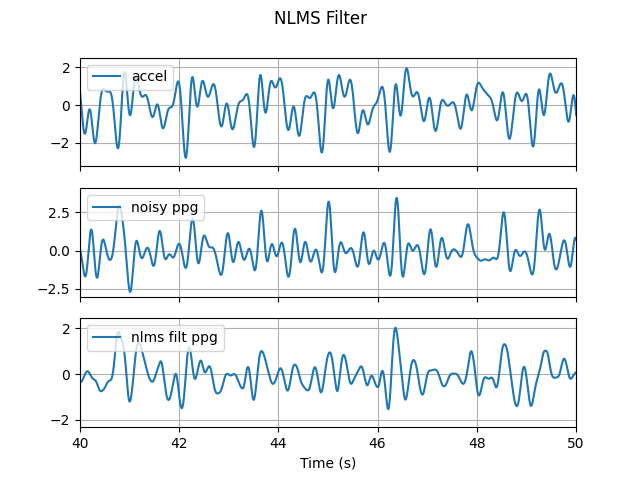

In [37]:
# Plot
fig, ax = plt.subplots(3,1, sharex=True)
ax[0].plot(t, accel_norm, label='accel')
ax[1].plot(t, ppg_norm, label='noisy ppg')
ax[2].plot(t, e_nlms, label='nlms filt ppg')
ax[2].set_xlabel('Time (s)')
fig.suptitle('NLMS Filter')
for axi in ax:
    axi.legend(loc='upper left')
    axi.grid(True)
    axi.set_xlim(40, 50)

In [38]:
# Comparison
hr_nlms = estimate_hr(e_nlms, fs)

print(f"HR ECG (ground truth): {hr_ecg:.1f} bpm")
print(f"HR raw PPG:            {hr_raw:.1f} bpm")
print(f"HR Wiener:             {hr_wiener:.1f} bpm")
print(f"HR LMS:                {hr_lms:.1f} bpm")
print(f"HR NLMS:                {hr_nlms:.1f} bpm")

HR ECG (ground truth): 99.0 bpm
HR raw PPG:            88.4 bpm
HR Wiener:             92.2 bpm
HR LMS:                96.7 bpm
HR NLMS:                94.3 bpm


## NLMS filter notes

- Same two ch set up as with LMS
- Only difference is step size normalized by current signal pwr estimate
- Variance removed: 64%
- HR estimate 94.3 vs 99 ECG ground truth and 96.7 LMS estimate
- Note: signal power might not change much over selected 30s window, meaning inherent advantage of NLMS not effective here; could explain why tuned LMS is just as good

# RLS Adaptive Filter

In [65]:
# RLS Adaptive filter implementation

lambda_ = 0.9999
delta = 1.0
P = delta ** -1 * np.eye(M)
w_rls = np.zeros(M)
e_rls = np.zeros(N)
k_rls = np.zeros(M)

for n in range(M, N):
    x_n = accel_norm[n - M : n]

    # Kalman gain
    k_rls = np.matmul(P, x_n) / (lambda_ + np.matmul(np.matmul(x_n.T, P), x_n))

    # Filter output
    y_n = np.dot(w_rls, x_n)

    # Error
    e_rls[n] = ppg_norm[n] - y_n

    # Update filter
    w_rls += k_rls * e_rls[n]

    # Update P
    P = (1 / lambda_) * (P - np.matmul(np.outer(k_rls, x_n), P))

    if n < M + 5:
        print(f"n={n} e={e_rls[n]:.4f} max|k|={np.max(np.abs(k_rls)):.4f} max|w|={np.max(np.abs(w_rls)):.4f}")

var_removed = np.var(ppg_norm) - np.var(e_rls)
pct_removed = 100 * var_removed / np.var(ppg_norm)
print(f"Variance removed: {pct_removed:.2f}%")

n=32 e=0.0710 max|k|=0.0617 max|w|=0.0044
n=33 e=0.0214 max|k|=0.0377 max|w|=0.0052
n=34 e=0.0248 max|k|=0.0316 max|w|=0.0060
n=35 e=0.0304 max|k|=0.0299 max|w|=0.0069
n=36 e=0.0363 max|k|=0.0300 max|w|=0.0080
Variance removed: 57.68%


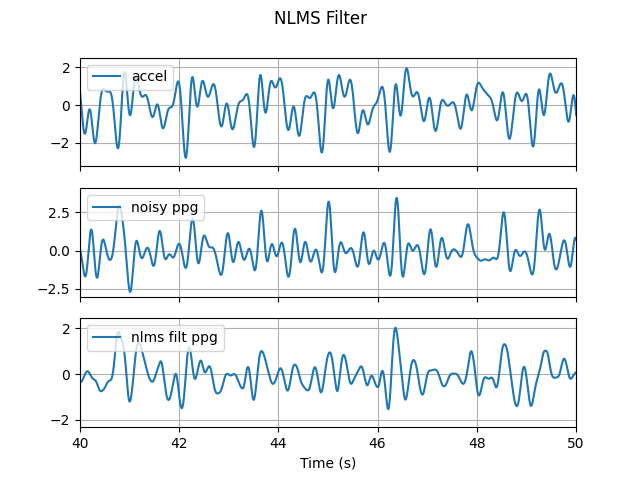

In [66]:
# Plot
fig, ax = plt.subplots(3,1, sharex=True)
ax[0].plot(t, accel_norm, label='accel')
ax[1].plot(t, ppg_norm, label='noisy ppg')
ax[2].plot(t, e_nlms, label='nlms filt ppg')
ax[2].set_xlabel('Time (s)')
fig.suptitle('NLMS Filter')
for axi in ax:
    axi.legend(loc='upper left')
    axi.grid(True)
    axi.set_xlim(40, 50)

In [67]:
# Comparison
hr_rls = estimate_hr(e_rls, fs)

print(f"HR ECG (ground truth): {hr_ecg:.1f} bpm")
print(f"HR raw PPG:            {hr_raw:.1f} bpm")
print(f"HR Wiener:             {hr_wiener:.1f} bpm")
print(f"HR LMS:                {hr_lms:.1f} bpm")
print(f"HR NLMS:                {hr_nlms:.1f} bpm")
print(f"HR RLS:                {hr_rls:.1f} bpm")

HR ECG (ground truth): 99.0 bpm
HR raw PPG:            88.4 bpm
HR Wiener:             92.2 bpm
HR LMS:                96.7 bpm
HR NLMS:                94.3 bpm
HR RLS:                94.8 bpm


## RLS filter notes

- Same two ch set up as with LMS
- Recursive least squares update — maintains running estimate of R^-1 via matrix P
- Expected faster convergence than LMS/NLMS (shown in rapid changes in signal which we don't have here)
- Variance removed: ~58%
- HR estimate 94.8 vs 99 ECG ground truth
- Forgetting factor lambda almost 1 (treating signal as almost stationary
    - Makes some sense given that NLMS had no improvement over LMS and 30 second window of data captures steady walking
 

(45.0, 50.0)

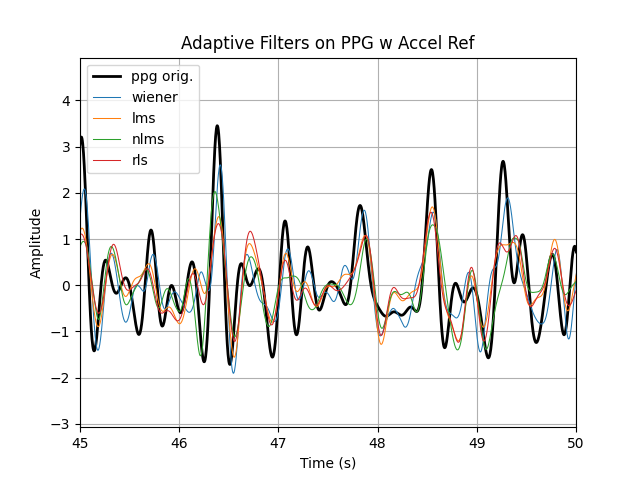

In [75]:
# Overall comparison

plt.close('all')
fig, ax = plt.subplots(1,1)
ax.plot(t, ppg_norm, label='ppg orig.', color='black', linewidth=2)
ax.plot(t, e_wiener, label='wiener', linewidth=0.75)
ax.plot(t, e_lms, label='lms', linewidth=0.75)
ax.plot(t, e_nlms, label='nlms', linewidth=0.75)
ax.plot(t, e_rls, label='rls', linewidth=0.75)
ax.legend(loc='upper left')
ax.set_title('Adaptive Filters on PPG w Accel Ref')
ax.grid(True)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_xlim(45, 50)
        


## Performance Summary

HR ECG (ground truth): 99.0 bpm
HR raw PPG:            88.4 bpm
HR Wiener:             92.2 bpm
HR LMS:                96.7 bpm
HR NLMS:                94.3 bpm
HR RLS:                94.8 bpm

## Results Summary
- All adaptive methods improve HR estimation over raw PPG (88.4 bpm)
- LMS performed best on this dataset: 96.7 bpm vs 99.0 bpm ECG ground truth
    - NLMS and RLS both comparable
- Wiener batch estimate weakest "adaptive" result
    - Fixed filter suboptimal for non-stationary artifact
- LMS outperforming NLMS and RLS could be because of steady-state walking
    - normalization and fast convergence provide little advantage over well-tuned fixed step size
- Linear adaptive filtering limited: CANNOT remove nonlinear accel artifacts

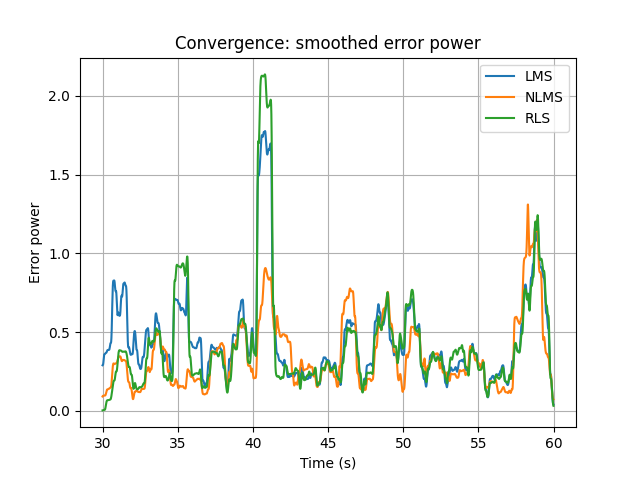

In [76]:
# Smoothed error power over time (convergence)

window = 256  # 1 second at 256 Hz
e_power_lms = np.convolve(e_lms**2, np.ones(window)/window, mode='same')
e_power_nlms = np.convolve(e_nlms**2, np.ones(window)/window, mode='same')
e_power_rls = np.convolve(e_rls**2, np.ones(window)/window, mode='same')

plt.figure()
plt.plot(t, e_power_lms, label='LMS')
plt.plot(t, e_power_nlms, label='NLMS')
plt.plot(t, e_power_rls, label='RLS')
plt.xlabel('Time (s)')
plt.ylabel('Error power')
plt.title('Convergence: smoothed error power')
plt.legend()
plt.grid(True)
plt.show()

## Convergence comparison

- All three adaptive methods track similarly during steady walking
- RLS most sensitive to sudden changes (high forgetting factor lambda=0.9999)